## Prepare the data

### 1. Load the tokenizer

In [1]:
import sys
sys.path.append('..')

In [2]:
from minbpe import RegexTokenizer

tokenizer = RegexTokenizer()
tokenizer.load(model_file="../output/tokenizer/my_tokenizer.model")


def get_vocab_size(tokenizer: RegexTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

### 2. Load the data

In [3]:
import json
import os
import pickle

file_path = "../output/fine_tuning/data/fine_tuning.json"
tokenized_cache_path = "../output/fine_tuning/data/fine_tuning_tokenized.pkl"

with open(file_path, "r") as file:
    data = json.load(file)

if os.path.exists(tokenized_cache_path):
    print("Loading tokenized data from cache...")
    with open(tokenized_cache_path, "rb") as f:
        tokenized_data = pickle.load(f)
else:
    print("Tokenizing data and saving to cache...")
    tokenized_data = []
    for item in data:
        tokenized_item = tokenizer.encode(item, allowed_special="all")
        tokenized_data.append(tokenized_item)

    with open(tokenized_cache_path, "wb") as f:
        pickle.dump(tokenized_data, f)

print(len(tokenized_data[0]))
print(len(tokenized_data))

Loading tokenized data from cache...
44
44510


### 3. Split the data

We need to be careful when splitting the data. Each multi-turn conversation should stay complete within a single set. To achieve this, we split the dataset, then ensure both the training and validation sets have an even number of elements. This helps keep pairs of `User 1` → `User 2` messages intact, so each set starts with a `User 1` message and ends with a `User 2` message.

In [4]:
split_index = int(0.95 * len(data))

# Make sure both halves have an even number of messages (complete pairs)
if len(data) % 2 != 0:
    data = data[:-1]

if split_index % 2 != 0:
    split_index -= 1

train_data = data[:split_index]
val_data = data[split_index:]

print(f"Training set [{len(train_data)}]: ")
print(f"Start message: {train_data[0].split('<|separator|>')[0]}")
print(f"End message: {train_data[-1].split('<|separator|>')[0]}")

print(f"\nValidation set [{len(val_data)}]: ")
print(f"Start message: {val_data[0].split('<|separator|>')[0]}")
print(f"End message: {val_data[-1].split('<|separator|>')[0]}")

Training set [42284]: 
Start message: <|startoftext|>Matteo Novembrini
End message: <|startoftext|>+39 342 603 2822

Validation set [2226]: 
Start message: <|startoftext|>France Palestra
End message: <|startoftext|>Tsu Zeri


We got the index that we should use to split the data. Now, let's split the tokenized data.

In [5]:
train_data = tokenized_data[:split_index]
val_data = tokenized_data[split_index:]

Now, we need to combine the `User 1` and `User 2` turns into one sequence. We will make sure that the resulting sequence does not exceed the `block_size`.

In [6]:
from variant_gpt.models import GPT2Config

block_size = GPT2Config().block_size


def combine_turns(data: list[list[int]], should_trim_long_sequences: bool) -> list[list[int]]:
    combined_turns_data = []
    trimmed = 0
    for i in range(0, len(data)-1):
        user_1_message = data[i]
        user_2_message = data[i+1]
        if not user_1_message or not user_2_message:
            continue

        final_message = user_1_message + user_2_message
        if len(final_message) > block_size and should_trim_long_sequences:
            trimmed += 1
            final_message = final_message[-block_size:]

        combined_turns_data.append(final_message)
    print(f"Trimmed {trimmed} sequences over {len(data)} because they exceeded the block size.")
    return combined_turns_data


combined_train_data = combine_turns(
    data=train_data,
    should_trim_long_sequences=True
)
combined_val_data = combine_turns(
    data=val_data,
    should_trim_long_sequences=True
)

Trimmed 20 sequences over 42284 because they exceeded the block size.
Trimmed 0 sequences over 2226 because they exceeded the block size.


In [7]:
print("Train data")
print(f"Length before: {len(train_data)}")
print(f"Length after: {len(combined_train_data)}")

print("\nValidation data")
print(f"Length before: {len(val_data)}")
print(f"Length after: {len(combined_val_data)}")

Train data
Length before: 42284
Length after: 42283

Validation data
Length before: 2226
Length after: 2225


We will merge the `User 1` and `User 2` parts into one sequence. Then, we will try to combine multiple sequences of `User 1` and `User 2` into a single input, but only if the sequence length stays smaller than the block size.

In [8]:
def merge_conversation_turns(combined_data: list[list[int]], block_size: int) -> list[list[int]]:
    new_data = []
    current_sequence = []

    for sequence in combined_data:
        if len(current_sequence) + len(sequence) <= block_size:
            current_sequence.extend(sequence)
        else:
            if current_sequence:
                new_data.append(current_sequence)
            current_sequence = sequence.copy()

    # Add the last block if it's not empty
    if current_sequence:
        new_data.append(current_sequence)

    return new_data


merged_train_data = merge_conversation_turns(
    combined_data=combined_train_data,
    block_size=block_size
)
merged_val_data = merge_conversation_turns(
    combined_data=combined_val_data,
    block_size=block_size
)

In [9]:
print(len(combined_train_data), len(merged_train_data))
print(len(combined_val_data), len(merged_val_data))

42283 3378
2225 184


Let's convert each sequence of tokens into a tensor.

Since our token sequences don't all have the same length, we can't turn the data into a tensor all at once. To do that, all sequences need to have the same length.

That's why we need to use padding to fix this problem. We can add padding at the start or end of the sequence. Let's add it to the end.

In [10]:
import torch
torch.manual_seed(3647)
torch.set_float32_matmul_precision('high')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
device_type = 'cuda' if 'cuda' in device else 'cpu'

# The token `<|padding|>` is used to mask the padding tokens.
# Masking means the model will ignore these tokens during training.
# In other words, the loss will not be calculated for these tokens.
padding_token = tokenizer.special_tokens["<|padding|>"]


def apply_padding_to_data(data: list[list[int]], block_size: int, padding_token: int) -> torch.Tensor:
    tensors = []
    for i in range(len(data)):
        tensor = torch.tensor(data[i])
        padded_tensor = torch.nn.functional.pad(
            input=tensor,
            pad=(0, block_size - len(tensor)), # right padding
            # pad=(block_size - len(tensor), 0), # left padding
            value=padding_token
        )
        tensors.append(padded_tensor)

    return torch.stack(tensors)


train_data_tensor = apply_padding_to_data(
    data=merged_train_data,
    block_size=block_size,
    padding_token=padding_token
)
val_data_tensor = apply_padding_to_data(
    data=merged_val_data,
    block_size=block_size,
    padding_token=padding_token
)

train_data_tensor.shape, val_data_tensor.shape

(torch.Size([3378, 1024]), torch.Size([184, 1024]))

In [11]:
train_data_tensor[0]

tensor([1024,  823,  353,  ..., 1028, 1028, 1028])

In [12]:
val_data_tensor[0]

tensor([1024,   70,  114,  ..., 1028, 1028, 1028])

### 4. Creat the data loaders

In [13]:
train_data_tensor.shape

torch.Size([3378, 1024])

In [14]:
from typing import Tuple
from torch.utils.data import Dataset, DataLoader


class FineTuningDataset(Dataset):
    def __init__(self, data: torch.Tensor, device: torch.device, padding_token: int):
        self.data = data  # shape: (num_samples, block_size)
        self.device = device
        self.padding_token = padding_token

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        sample = self.data[index]
        x = sample.to(self.device)
        y = sample[1:].to(self.device)
        padding_tensor = torch.tensor([self.padding_token], device=self.device)
        y = torch.cat((y, padding_tensor))
        return x, y


batch_size = 96
device = torch.device(device)

train_dataset = FineTuningDataset(
    data=train_data_tensor,
    device=device,
    padding_token=padding_token
)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_dataset = FineTuningDataset(
    data=val_data_tensor,
    device=device,
    padding_token=padding_token
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [15]:
x, y = next(iter(train_loader))
x.shape, y.shape

(torch.Size([96, 1024]), torch.Size([96, 1024]))

## Fine-tuning

### 1. Load the saved checkpoint

In [16]:
from variant_gpt.models import GPT2Config, GPT2Model

config = GPT2Config(
    vocab_size=get_vocab_size(tokenizer),
    dropout=0.15,
    device=device,
    flash=True
)

model = GPT2Model(config)
model = torch.compile(model)

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

number of parameters: 85.75M
86.5344 M parameters


In [17]:
checkpoint_path = "../output/pre_training/run_4_1/checkpoint_best.pth"
checkpoint = torch.load(checkpoint_path, map_location=config.device, weights_only=True)
model_state_dict = checkpoint["model_state_dict"]
model.load_state_dict(model_state_dict)

<All keys matched successfully>

Generate from the model to make sure that the weights were loaded correctly.

In [18]:
input_tokens = tokenizer.encode("Buongiorno ", allowed_special="all")
input_tokens = torch.tensor(
    input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

Buongiorno Grazie Livio!!! 🎉🍾  Auguri gustaa Auguroni Auguri AUGURIIIIIII Baongiorno ZI Auguri ber! Auguristeriii Auguri gab Auguri sep!! Auguriiiiiii 📦🐗🦧 Auguroni🥳🥳 Auguri rion compleanno del di megno del Presidente Auguri Pen⁩!!! Auguri!! Auguroni nnaccinooo!!!! Auguri P


### 2. Estimate loss

In [19]:
from typing import Dict


@torch.no_grad()
def estimate_loss(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader
) -> Dict[str, float]:
    was_training = model.training
    model.eval()

    results: Dict[str, float] = {}

    for split_name, loader in [('train', train_loader), ('val', val_loader)]:
        losses = []
        for i, (x, y) in enumerate(loader):
            # Expecting model to return (logits, loss)
            with torch.autocast(device_type, dtype=torch.bfloat16):
                _, loss = model(x, y)
            losses.append(loss.item())

        results[split_name] = float(torch.tensor(losses).mean())

    if was_training:
        model.train()

    return results

### 3. Save checkpoints

In [20]:
import os

class CheckpointManager:
    """Keeps the last `keep_last` periodic checkpoints plus the single best."""

    @staticmethod
    def _save_checkpoint(
            model: GPT2Model,
            optimizer: torch.optim.Optimizer,
            epoch: int,
            loss: float,
            file_path: str = "checkpoint.pth"
    ) -> None:
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss
        }
        torch.save(checkpoint, file_path)

    def __init__(self, checkpoint_dir: str, keep_last: int = 3):
        self.checkpoint_dir = checkpoint_dir
        self.keep_last = keep_last
        self._periodic: list[str] = []   # ordered oldest → newest
        self._best: str | None = None

    def save_periodic(self, model, optimizer, epoch, loss, batch_idx) -> str:
        path = os.path.join(self.checkpoint_dir, f"checkpoint_{epoch}_{batch_idx}.pth")
        self._save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=loss, file_path=path)
        self._periodic.append(path)
        self._evict_old()
        return path

    def save_epoch(self, model, optimizer, epoch, loss) -> str:
        path = os.path.join(self.checkpoint_dir, f"checkpoint_{epoch}.pth")
        self._save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=loss, file_path=path)
        self._periodic.append(path)
        self._evict_old()
        return path

    def save_best(self, model, optimizer, epoch, loss) -> str:
        path = os.path.join(self.checkpoint_dir, "checkpoint_best.pth")
        if self._best:
            os.remove(self._best)
        self._save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=loss, file_path=path)
        self._best = path
        return path

    def _evict_old(self):
        """Delete periodic checkpoints beyond the keep_last window."""
        while len(self._periodic) > self.keep_last:
            oldest = self._periodic.pop(0)
            if oldest != self._best and os.path.exists(oldest):
                os.remove(oldest)

### 4. Early stopping

In [21]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_val_loss = float('inf')
        self.stale_count = 0

    @property
    def should_stop(self) -> bool:
        return self.stale_count >= self.patience

    def step(self, val_loss: float) -> bool:
        """Update state. Returns True if this is a new best."""
        if val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self.stale_count = 0
            return True
        self.stale_count += 1
        return False

### 5. Training loop

In [22]:
import os
from tqdm.notebook import tqdm

# ── Hyperparameters ────────────────────────────────────────────────────────────
max_iters      = 490
eval_interval  = 35
grad_clip      = 1.0          # max gradient norm; prevents exploding gradients

early_stopping = EarlyStopping(patience=5, min_delta=1e-4)

# ── Optimizer + scheduler ──────────────────────────────────────────────────────
weight_decay = 1e-1
learning_rate  = 1e-5
beta1 = 0.9
beta2 = 0.95
optimizer = model.configure_optimizers(weight_decay, learning_rate, (beta1, beta2), device_type)

# Cosine annealing decays LR smoothly over training; last_epoch=-1 starts fresh.
total_steps = max_iters * len(train_loader)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=learning_rate * 0.1)

# ── History ────────────────────────────────────────────────────────────────────
train_losses = []
val_losses = []

# ── Training ───────────────────────────────────────────────────────────────────
CHECKPOINT_DIR = "../output/fine_tuning/run_6_2"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

ckpt_manager = CheckpointManager(CHECKPOINT_DIR, keep_last=3)

model.train()
for iteration in range(max_iters):
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f"Epoch {iteration+1}/{max_iters}"
    )

    for batch_idx, (x_batch, y_batch) in progress_bar:
        # Training step
        optimizer.zero_grad(set_to_none=True)

        # Mixed precision: speeds up training and reduces memory, especially on Ampere+ GPUs.
        with torch.autocast(device_type, dtype=torch.bfloat16):
            logits, loss = model(x_batch, y_batch)
        loss.backward()

        # Gradient clipping: keeps updates stable when loss spikes
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({
            "lr":    f"{scheduler.get_last_lr()[0]:.2e}",
            "stale": f"{early_stopping.stale_count}/{early_stopping.patience}"
        })

        # ── Periodic checkpoint (interval or final batch) ──────────────────────
        is_eval_step  = batch_idx > 0 and batch_idx % eval_interval == 0
        is_final_step = batch_idx == len(train_loader) - 1

        if is_eval_step or is_final_step:
            losses = estimate_loss(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader
            )
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

            tqdm.write(
                f"[Epoch {iteration + 1} | Step {batch_idx:>5d}] "
                f"Train: {losses['train']:.4f} | "
                f"Val: {losses['val']:.4f} | "
                f"LR: {scheduler.get_last_lr()[0]:.2e}"
            )

            # ── Early stopping + best-model checkpoint ─────────────────────────
            if early_stopping.step(losses['val']):
                tqdm.write(f"  ✅ New best val loss: {early_stopping.best_val_loss:.4f}")
                ckpt_manager.save_best(
                    model=model, optimizer=optimizer,
                    epoch=iteration, loss=losses['val'],
                )
            else:
                tqdm.write(f"  ⚠️  Stale eval {early_stopping.stale_count}/{early_stopping.patience}")

            # ── Periodic snapshot (separate from best-model logic) ─────────────
            if is_eval_step:
                ckpt_manager.save_periodic(
                    model=model, optimizer=optimizer, batch_idx=batch_idx,
                    epoch=iteration, loss=losses["val"],
                )

            if early_stopping.should_stop:
                break

    if early_stopping.should_stop:
        tqdm.write(f"\n🛑 Early stopping triggered — no improvement for {early_stopping.patience} evaluations.")
        break

    # End-of-epoch snapshot using the last *validated* loss
    last_val = val_losses[-1] if val_losses else float("nan")
    ckpt_manager.save_epoch(
        model=model, optimizer=optimizer,
        epoch=iteration, loss=last_val,
    )

tqdm.write("\nTraining completed ✅")

num decayed parameter tensors: 50, with 86,515,200 parameters
num non-decayed parameter tensors: 25, with 19,200 parameters
using fused AdamW: True


Epoch 1/490:   0%|          | 0/36 [00:00<?, ?it/s]

[Epoch 1 | Step    35] Train: 2.4820 | Val: 2.5675 | LR: 1.00e-05
  ✅ New best val loss: 2.5675


Epoch 2/490:   0%|          | 0/36 [00:00<?, ?it/s]

[Epoch 2 | Step    35] Train: 2.1888 | Val: 2.2804 | LR: 1.00e-05
  ✅ New best val loss: 2.2804


...

[Epoch 196 | Step    35] Train: 0.7136 | Val: 0.9748 | LR: 6.89e-06
  ⚠️  Stale eval 3/5


Epoch 197/490:   0%|          | 0/36 [00:00<?, ?it/s]

[Epoch 197 | Step    35] Train: 0.7128 | Val: 0.9745 | LR: 6.86e-06
  ⚠️  Stale eval 4/5


Epoch 198/490:   0%|          | 0/36 [00:00<?, ?it/s]

[Epoch 198 | Step    35] Train: 0.7118 | Val: 0.9732 | LR: 6.84e-06
  ⚠️  Stale eval 5/5

🛑 Early stopping triggered — no improvement for 5 evaluations.

Training completed ✅


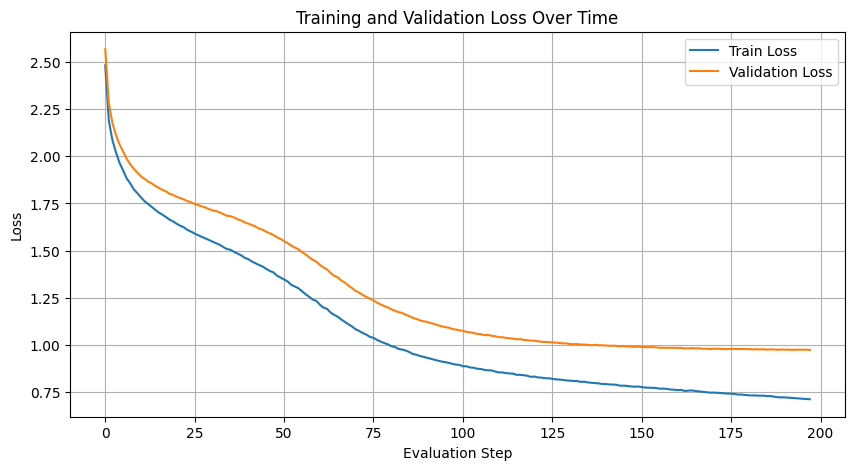

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [ ]:
def get_input_tokens(message: str) -> torch.Tensor:
    input_tokens = tokenizer.encode(
        f"<|startoftext|>{message}<|separator|>", allowed_special="all")
    input_tokens = torch.tensor(
        input_tokens, dtype=torch.long).unsqueeze(0).to(device)
    return input_tokens


user_message = "A che ore è la partita?"
input_tokens = get_input_tokens(message=user_message)
model_answer = ""

model.eval()
while True:
    output_tokens = model.generate(input_tokens=input_tokens, max_new_tokens=1)
    last_generated_token = output_tokens[0, -1].item()
    if last_generated_token == tokenizer.special_tokens["<|endoftext|>"]:
        break

    input_tokens = torch.cat((input_tokens, output_tokens[:, -1:]), dim=1)
    model_answer += tokenizer.decode([last_generated_token])

    if len(output_tokens[0]) > block_size:
        input_tokens = input_tokens[:, -block_size:]

print(f"User 1: {user_message}")
print(f"User 2: {model_answer}")